In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import math
from scipy import stats
from collections import Counter
from statsmodels.stats.proportion import proportions_ztest
import sys
sys.path.append('C:\\Users\\sonia\\OneDrive - University of Pittsburgh\\Sonia Kruszelnicki')
from labFunctions import *

peakAnnofile = '20260127_rehmanunionpeakAnno.csv'

fit7LFCfile = "C:\\Users\\sonia\\OneDrive - University of Pittsburgh\\Sonia Kruszelnicki\\Papers\\AMNetworkPaper\\20250327_fit7_DE_LFCs.csv"

motif_fams_dict = pickleDeserialize("motif_fams_dict.pickle")

chrombpnetTFs = pickleDeserialize("chrombpnetTFs.pickle")

In [2]:
def groupMotifFamilies2(exp_df, motif_fams):
    TFs = list(exp_df.index)
    fam_assignments = dict()
    for TF in TFs:
        for fam in motif_fams.keys():
            fam_TFs = set([x.capitalize() for x in motif_fams[fam]])
            if TF.capitalize() in fam_TFs:
                fam_assignments[TF] = fam
                break
            else: 
                fam_assignments[TF] = "NA"
    final = exp_df.copy().reset_index()
    final['family'] = final['index'].apply(lambda x: fam_assignments[x])
    final = final.set_index('index')
    return final

def getTopicGenes(topicDF, topic, thresh):
    current = topicDF[topic].sort_values(ascending=False)
    if thresh == 'pos':
        top = set(current[current > 0].index)
    else:
        top = set(current[:thresh].index)
    return top

def motifTargetTopicScatter(annot, motifs, topicdict):
    subset = topicdict.keys()
    new = annot.loc[:, ['V4', 'SYMBOL', 'annotation']].query('V4 in @motifs').query('SYMBOL in @subset').query('annotation in @promoterTags')
    new = new.groupby(new.columns.tolist(),as_index=False).size()
    new['topicLFC'] = new['SYMBOL'].apply(lambda x: topicdict[x])
    plt.figure(figsize = (20, 15))
    sns.scatterplot(data = new, x='size', y='topicLFC', hue='V4', size='annotation', size_order=["Promoter (<=1kb)","Promoter (1-2kb)",  "Promoter (2-3kb)"])
    return new

def motifCountsDict(annot, topic, motifs, region):
    d = annot.query('SYMBOL in @topic').query('V4 in @motifs').query('annotation in @region').groupby('SYMBOL')['V4'].unique().to_dict()
    for i, x in enumerate(d.keys()):
        if i == 0:
            c = list(d[x])
        else:
            curr = d[x]
            c.extend(list(curr))
    counted = Counter(c)
    return counted, len(counted.keys())
    
def compareTopicRegulators(annot, topic1, topic2, motifs, region, leg):
    d1, ld1 = motifCountsDict(annot, topic1, motifs, region)
    d2, ld2 = motifCountsDict(annot, topic2, motifs, region)
    df1 = pd.DataFrame.from_dict(d1, orient='index').rename(columns = {0: 'topicA'})
    df2 = pd.DataFrame.from_dict(d2, orient='index').rename(columns = {0: 'topicB'})
    p = df1.join(df2, how='outer').fillna(0).reset_index()
    slope, intercept, r_value, p_value, std_err = stats.linregress(p['topicA'], p['topicB'])
    plt.figure(figsize = (12, 9))
    sns.lmplot(data=p, x = 'topicA', y='topicB', hue='index', fit_reg=True, palette='rainbow', legend = leg)
    plt.title('slope = ' + str(slope))
    return p

def wilson_interval(successes, n, confidence=0.95):
    p_hat = successes / n
    z = stats.norm.ppf(1 - (1 - confidence) / 2)  # e.g., 1.96 for 95% CI
    
    denominator = 1 + z**2 / n
    center = (p_hat + z**2 / (2 * n)) / denominator
    margin = (z * np.sqrt((p_hat * (1 - p_hat) + z**2 / (4 * n)) / n)) / denominator
    
    lower = center - margin
    upper = center + margin
    return center

def ztest(df):
    zlist = []
    plist = []
    for tf in df.itertuples():
        nlist = [tf[3]] * 2
        stat, pval = proportions_ztest([tf[1], tf[2]], nlist)
        zlist.append(stat)
        plist.append(pval)
    df['z_value'] = zlist
    df['p_value'] = plist
    return df

def compileTopicRegStats(df):
    df = df.set_index('index')
    df['sum'] = list(df.aggregate(sum, axis=1))
    df = ztest(df)
    df['-log10(pval)'] = df['p_value'].apply(lambda x: -math.log10(x))
    #df['wilson_ci'] = df.apply(lambda row: wilson_interval(row['topicA'], row['sum']), axis=1)
    df['ratioAB'] = df['topicA'] / df['topicB']
    return df

def calcEnrichmentPval(annot, motif, topic):
    background = set(annot['SYMBOL'].unique())
    motif_genes = set(annot.query('V4 == @motif')['SYMBOL'].unique())
    topic_genes = set(annot.query('SYMBOL in @topic')['SYMBOL'].unique())
    motiftopic_genes = set(annot.query('V4 == @motif').query('SYMBOL in @topic')['SYMBOL'].unique())
    oddsratio, pvalue = fisher_exact([[len(motiftopic_genes), len(motif_genes - motiftopic_genes)], [len(topic_genes - motiftopic_genes), len(background - motif_genes - topic_genes)]], alternative='greater')
    return pvalue

def calcAvgContributions(df):
    fin = dict()
    for m in df['V4'].unique():
        current = df.query('V4 == @m')
        avg = current['score'].mean()
        fin[m] = {'Avg Contribution': avg}
    fin_df = pd.DataFrame.from_dict(fin, orient='index').rename(index = {'COUP-TFII': 'NR2F2', 'BMAL1': 'Arntl', 'Fra1':'Fosl1', 'Fra2':'Fosl2'})
    return fin_df

In [3]:
#load peak annotations
annot = pd.read_csv(peakAnnofile, index_col=0)
annot['V4'] = annot['V4'].apply(lambda x: x.split('(')[0])
annot

,seqnames,start,end,width,strand,V4,V5,V6,annotation,geneChr,geneStart,geneEnd,geneLength,geneStrand,geneId,transcriptId,distanceToTSS,ENSEMBL,SYMBOL,GENENAME
1,chrY,1286515,1286524,10,*,AP-1,7.191235,+,Promoter (<=1kb),21,1262313,1286582,24270,2,26900,ENSMUST00000188484.1,58.0,ENSMUSG00000069045,Ddx3y,"DEAD box helicase 3, Y-linked"
2,chrY,1286514,1286523,10,*,AP-1,7.091934,-,Promoter (<=1kb),21,1262313,1286582,24270,2,26900,ENSMUST00000188484.1,59.0,ENSMUSG00000069045,Ddx3y,"DEAD box helicase 3, Y-linked"
3,chrY,1163187,1163196,10,*,AP-1,6.249357,+,Promoter (5-6kb),21,1160804,1169186,8383,2,22290,ENSMUST00000133976.1,5990.0,ENSMUSG00000068457,Uty,ubiquitously transcribed tetratricopeptide rep...
4,chrY,1163255,1163264,10,*,AP-1,7.558394,+,Promoter (5-6kb),21,1160804,1169186,8383,2,22290,ENSMUST00000133976.1,5922.0,ENSMUSG00000068457,Uty,ubiquitously transcribed tetratricopeptide rep...
5,chrY,1163254,1163263,10,*,AP-1,8.785984,-,Promoter (5-6kb),21,1160804,1169186,8383,2,22290,ENSMUST00000133976.1,5923.0,ENSMUSG00000068457,Uty,ubiquitously transcribed tetratricopeptide rep...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7054960,chr1,35839673,35839692,20,*,ZSCAN22,10.201980,-,Distal Intergenic,1,36068400,36106446,38047,1,50785,ENSMUST00000088174.3,-228708.0,ENSMUSG00000045216,Hs6st1,heparan sulfate 6-O-sulfotransferase 1
7054961,chr1,35813814,35813833,20,*,ZSCAN22,11.933972,+,Distal Intergenic,1,36068400,36106446,38047,1,50785,ENSMUST00000088174.3,-254567.0,ENSMUSG00000045216,Hs6st1,heparan sulfate 6-O-sulfotransferase 1
7054962,chr1,31050491,31050510,20,*,ZSCAN22,10.245777,+,Promoter (45-46kb),1,31019188,31096454,77267,2,102634473,ENSMUST00000188605.1,45944.0,ENSMUSG00000086727,Gm29669,predicted gene 29669
7054963,chr1,16519442,16519461,20,*,ZSCAN22,12.371171,-,Promoter (<=1kb),1,16345594,16519307,173714,2,29819,ENSMUST00000149320.8,-135.0,ENSMUSG00000025920,Stau2,staufen double-stranded RNA binding protein 2


In [4]:
#had previously defined promoter as +-100kb from TSS, so create filter for all "promoters"
promoterTags = set()
for i in annot['annotation'].unique():
    if i[:8] == 'Promoter':
        promoterTags.add(i)

In [5]:
#count motifs, some were renamed to their better known name
filt = annot.rename(index = {'COUP-TFII': 'NR2F2'})
rawMotifcount = pd.DataFrame.from_dict(Counter(filt['V4']), orient = 'index', columns=['count'])
rawMotifcount = rawMotifcount.rename(index = {'COUP-TFII': 'NR2F2', 'BMAL1': 'Arntl', 'Fra1':'Fosl1', 'Fra2':'Fosl2'})
rawMotifcount = groupMotifFamilies2(rawMotifcount, motif_fams_dict)

In [6]:
#get the top genes from topics 4 and 7
fit7LFC = pd.read_csv(fit7LFCfile, index_col=0).sort_values(by='k7', ascending=False)
k7LFC = fit7LFC['k7']
topic7 = getTopicGenes(fit7LFC, 'k7', 1000)
topic4 = getTopicGenes(fit7LFC, 'k4', 1000)

In [7]:
#find the enrichment of the TF motifs in the topic gene "promoter" regions
fin = dict()
for m in filt['V4'].unique():
    mtopic7_pval = -math.log(calcEnrichmentPval(filt, m, topic7))
    mtopic4_pval = -math.log(calcEnrichmentPval(filt, m, topic4))
    fin[m] = {'topic7_-log(pval)': mtopic7_pval, 'topic4_-log(pval)': mtopic4_pval}
topicEnrichment = pd.DataFrame.from_dict(fin, orient='index').rename(index = {'COUP-TFII': 'NR2F2', 'BMAL1': 'Arntl', 'Fra1':'Fosl1', 'Fra2':'Fosl2'})

In [8]:
motifdf = rawMotifcount.join(topicEnrichment).rename(index = {'COUP-TFII': 'NR2F2', 'BMAL1': 'Arntl', 'Fra1':'Fosl1', 'Fra2':'Fosl2'})

In [9]:
#load the avergage contribution scores for each motif by HOMER for naive basal condition
avgContribfile = '20250617_allMotifs_NBprofileContribAvg.bed'
NBcounts = pd.read_csv(avgContribfile, sep='\t', header=None).rename(columns=dict(zip([0,1,2,3, 4],['seqnames', 'start', 'end', 'V4', 'score'])))
NBcounts['V4'] = NBcounts['V4'].apply(lambda x: x.split('(')[0])
NBcounts

,seqnames,start,end,V4,score
0,chr1,194671997,194672007,AP-1,0.067585
1,chr1,194672046,194672056,AP-1,0.068692
2,chr1,194672640,194672650,AP-1,0.000000
3,chr1,194672045,194672055,AP-1,0.065518
4,chr1,194671996,194672006,AP-1,0.066181
...,...,...,...,...,...
7059078,chrY_JH584301_random,93279,93289,Nkx3.1,0.005067
7059079,chrY_JH584301_random,93179,93189,SPDEF,0.048610
7059080,chrY_JH584301_random,93168,93176,Tbx5,0.009401
7059081,chrY_JH584301_random,93167,93175,Tgif1,0.011047


Text(0.5, 1.0, 'Average Motif Contribution Score Distrubution')

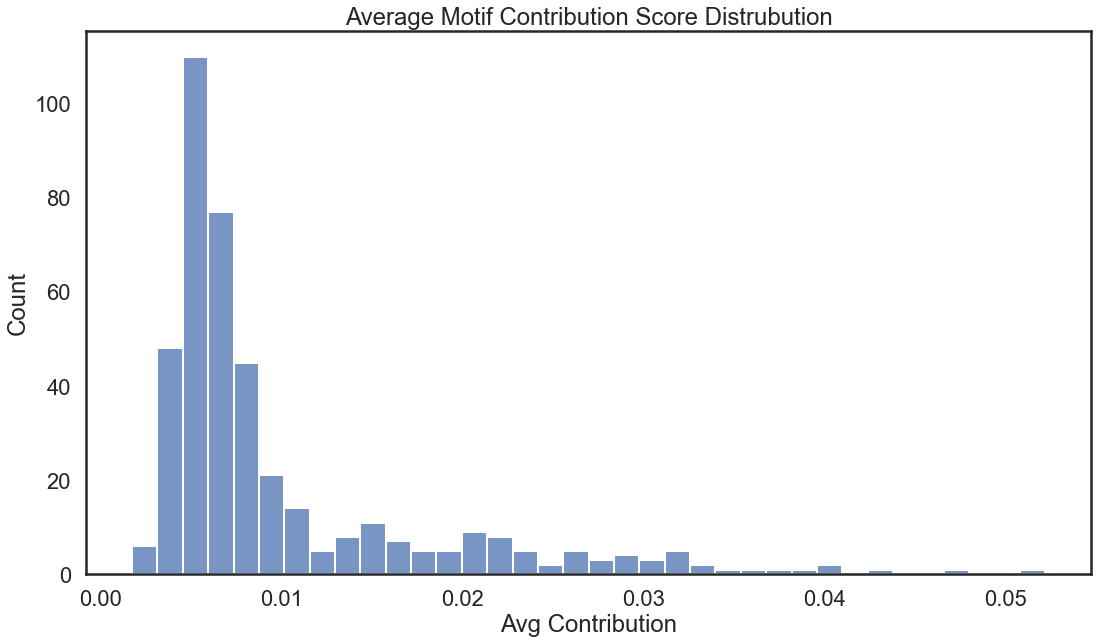

In [10]:
#calculate and show distribution of the of each motif's average contribution score
NBcounts_avgs = calcAvgContributions(NBcounts)
plt.figure(figsize = (18, 10))
sns.set_theme('poster')
sns.set_style('white')
sns.histplot(data=NBcounts_avgs, x='Avg Contribution')
plt.title('Average Motif Contribution Score Distrubution')

In [11]:
#data for naive injury condition - 3 day LPS
NIcounts = pd.read_csv('20250617_allMotifs_NIprofileContribAvg.bed', sep='\t', header=None).rename(columns=dict(zip([0,1,2,3, 4],['seqnames', 'start', 'end', 'V4', 'score'])))
NIcounts['V4'] = NIcounts['V4'].apply(lambda x: x.split('(')[0])
NIcounts_avgs = calcAvgContributions(NIcounts)

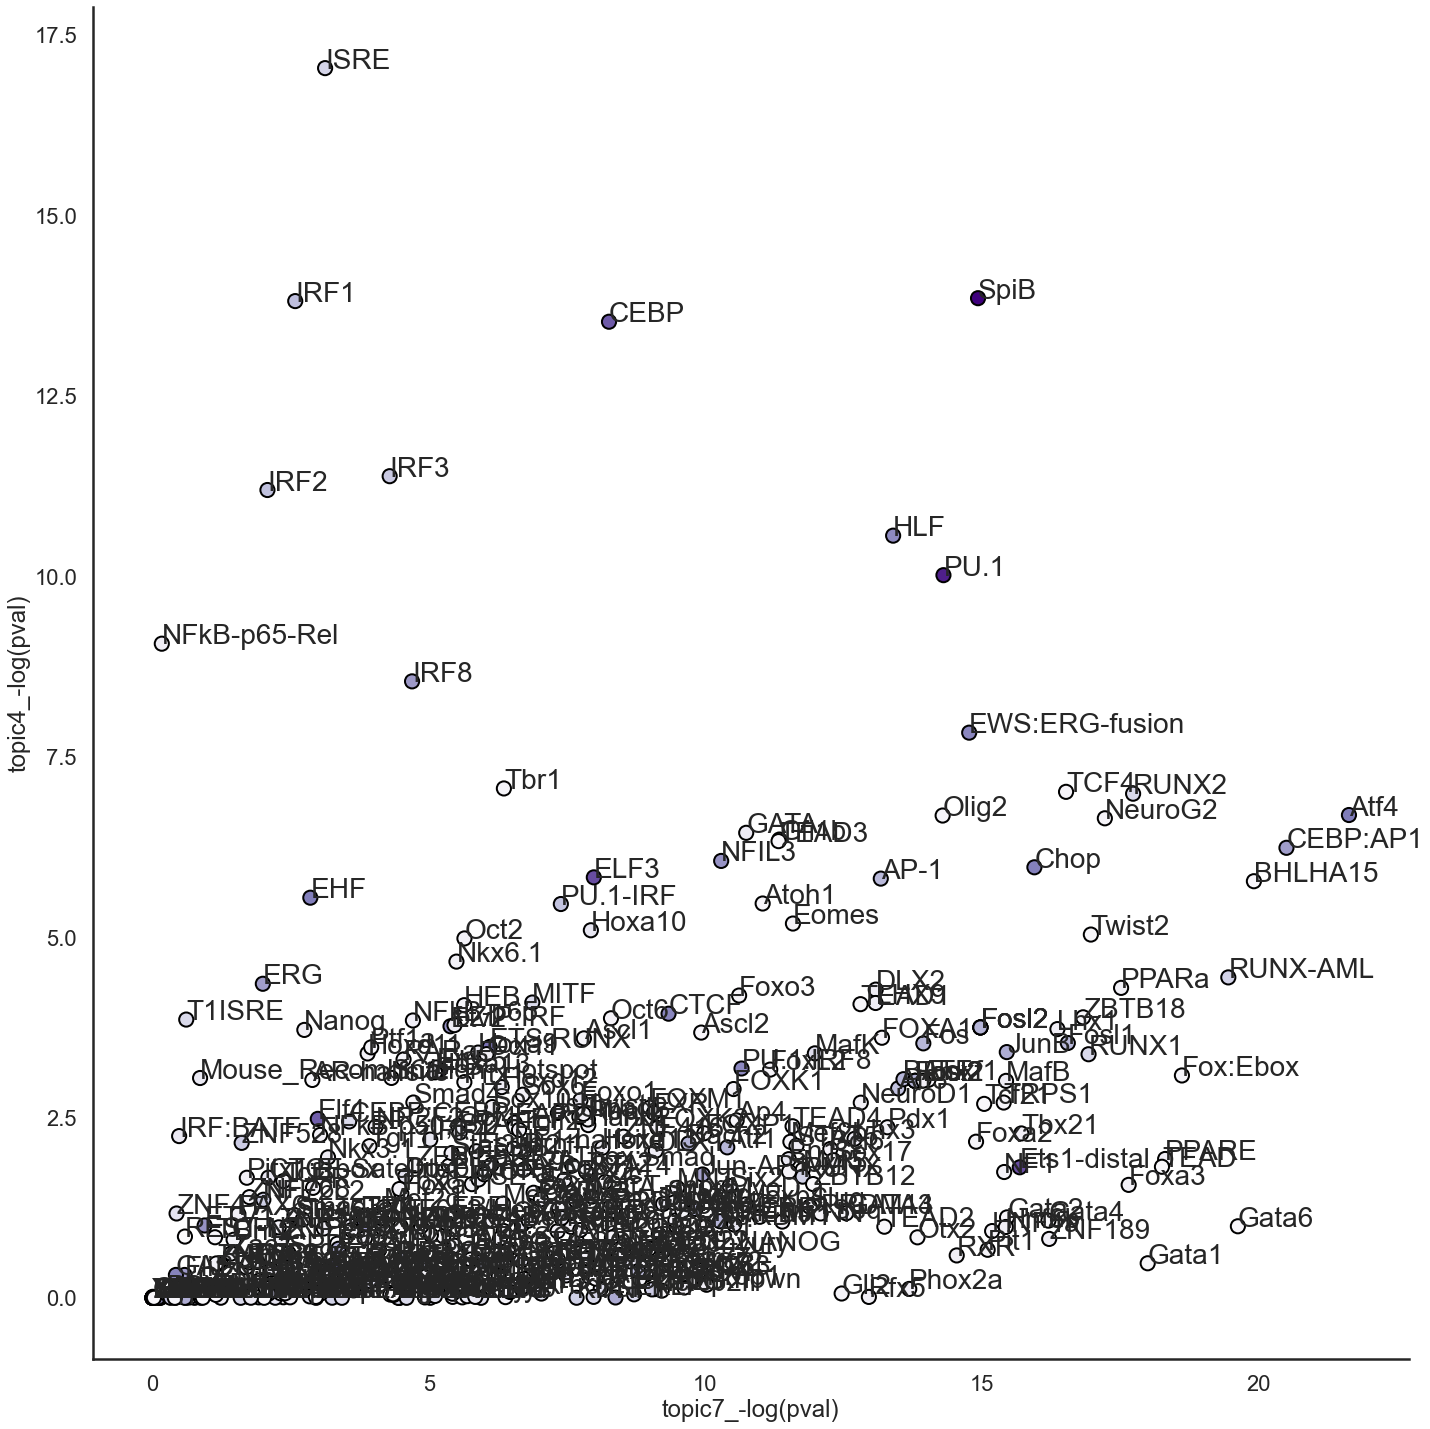

In [15]:
#scatterplot of motif enrichment in topics 4 and 7, colored by average contribution score
motifdf2 = motifdf.join(NBcounts_avgs).rename(index = {'COUP-TFII': 'NR2F2', 'BMAL1': 'Arntl', 'Fra1':'Fosl1', 'Fra2':'Fosl2'})
max_abs_score = np.max(np.abs(motifdf2['Avg Contribution']))
#norm = plt.Normalize(-max_abs_score, max_abs_score)
cmap = plt.get_cmap('Purples')
plt.rcParams["figure.figsize"] = (20,3)

def scatter_with_annotations(data, x, y, **kwargs):
    ax = plt.gca()
    sc = ax.scatter(
        data[x], data[y],
        c=data['Avg Contribution'],
        cmap=cmap,
        #norm=norm,
        edgecolors='black',
        s=200
    )
    # Annotate points
    for _, row in data.iterrows():
        if True:
            ax.text(row[x], row[y], row['index'], fontsize=28, ha='left')
    return sc

g = sns.FacetGrid(motifdf2.reset_index(), height=20, sharey=False, sharex=False)
g.map_dataframe(scatter_with_annotations, x='topic7_-log(pval)', y='topic4_-log(pval)')
#sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
#sm = plt.cm.ScalarMappable(cmap=cmap)
#sm.set_array([])
#g.fig.colorbar(sm, ax=g.axes, label='Avg Contribution')
plt.xlabel('topic7_-log(pval)')
plt.ylabel('topic4_-log(pval)')
plt.savefig('20260306_NBcountContrib_topicRegulatorScatter.pdf')